<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Topic 1 : Why CNN
    Topic 2 : CNN vs ANN
    Topic 3 : Image Representation
    Topic 4 : Convolution Operation
    Topic 5 : Filters and Kernels
    Topic 6 : Stride
    Topic 7 : Padding
    Topic 8 : Feature Maps
    Topic 9 : Pooling
        Max Pooling
        Average Pooling
        Global Average Pooling
    Topic 10 : CNN Architectures
        LeNet
        AlexNet
        VGG
        GoogLeNet (Inception)
        ResNet
        DenseNet
        EfficientNet
    Topic 11 : Transfer Learning
    Topic 12 : Data Augmentation
    Topic 13 : Hyperparameters
    Topic 14 : CIFAR-10 Project

## Topic 1: Why CNN?

### Definition

A **Convolutional Neural Network (CNN)** is a specialized type of deep neural network primarily designed to process and analyze visual data, such as images and videos. Unlike traditional neural networks (like ANNs or Fully Connected Networks), CNNs are particularly effective at identifying patterns and features directly from raw pixel data, making them ideal for tasks like image classification, object detection, and segmentation.

### Why CNN?

CNNs were developed to address the inherent challenges of processing high-dimensional data like images. Images consist of a grid of pixels, and for even a small image, the number of input features can be enormous. CNNs leverage a hierarchical approach to learn features, starting from simple edges and textures to more complex patterns and objects.

### Why ANN fails for images? & Problems with Fully Connected Networks

Traditional Artificial Neural Networks (ANNs) or Fully Connected Networks (FCNs) connect every neuron in one layer to every neuron in the next layer. While effective for tabular data, they face significant challenges when applied to images:

1.  **High Dimensionality:** An image of size 28x28 pixels (grayscale) has 784 pixels. For an RGB image, this becomes 28x28x3 = 2352 input features. For larger images, say 200x200 pixels, it's 200x200x3 = 120,000 features. In an FCN, each of these features would be an input to the first hidden layer. If the first hidden layer has 1000 neurons, that's 120,000 * 1000 = 120,000,000 weights just for the first layer, leading to an explosion of parameters.

2.  **Loss of Spatial Information:** FCNs flatten the image into a 1D vector, destroying the spatial relationships between pixels. The proximity of pixels is crucial for recognizing visual patterns (e.g., an edge is formed by adjacent pixels).

3.  **Lack of Translation Invariance:** If a feature (e.g., an eye) appears in a different location in an image, an FCN would have to learn that feature again. This means an FCN is highly sensitive to the position of features.

4.  **Inefficient Feature Learning:** FCNs struggle to learn hierarchical patterns efficiently. They don't naturally understand that certain features are combinations of other simpler features.

### Motivation

The motivation behind CNNs is to overcome the limitations of FCNs for image processing by incorporating principles inspired by the human visual cortex. Key motivations include:

*   **Parameter Reduction:** Drastically reduce the number of parameters by using shared weights (filters/kernels) and sparse connectivity.
*   **Preserving Spatial Information:** Maintain the 2D (or 3D) structure of the input, allowing the network to capture local spatial relationships.
*   **Translation Invariance:** Enable the network to recognize features regardless of their position in the image through local receptive fields and pooling.
*   **Hierarchical Feature Learning:** Automatically learn features at different levels of abstraction, from simple edges to complex object parts, without explicit feature engineering.

### CNN vs ANN

| Feature               | Artificial Neural Network (ANN)                               | Convolutional Neural Network (CNN)                                 |
| :-------------------- | :------------------------------------------------------------ | :----------------------------------------------------------------- |
| **Input Data**        | Typically 1D vector (flattened data)                          | 2D/3D (e.g., image, volume)                                        |
| **Connectivity**      | Fully connected (each neuron to every neuron in next layer)   | Locally connected (neurons connect only to a local region)         |
| **Weight Sharing**    | No                                                            | Yes (filters applied across the entire input)                      |
| **Spatial Info**      | Lost (due to flattening)                                      | Preserved                                                          |
| **Parameters**        | Very high for image data                                      | Significantly lower for image data                               |
| **Translation Inv.**  | Poor                                                          | Good (due to local receptive fields and pooling)                   |
| **Primary Use**       | Tabular data, text, simple patterns                           | Image recognition, object detection, video analysis                |

### Advantages of CNNs

*   **Parameter Efficiency:** Shared weights and local connections drastically reduce the number of learnable parameters, making them more scalable.
*   **Spatial Hierarchy:** Naturally learn spatial hierarchies of features, from low-level edges to high-level object concepts.
*   **Translation Invariance:** Able to detect features regardless of their exact position in the image.
*   **Feature Extraction:** Automatically learn relevant features from raw data, reducing the need for manual feature engineering.
*   **Better Performance:** Outperform ANNs and other traditional methods in image-related tasks.

### Limitations of CNNs

*   **Computational Cost:** Can still be computationally expensive, especially with very deep architectures and high-resolution images.
*   **Data Hungry:** Require large amounts of labeled data for optimal performance.
*   **Lack of Rotational and Scale Invariance (to some extent):** While translation invariant, CNNs are not inherently invariant to rotations and changes in scale without data augmentation or specific architectural additions.
*   **Interpretability:** Can be difficult to interpret what features a specific layer or filter is detecting.

### Numerical Example: Parameter Count Comparison

Let's consider a simple example to illustrate the difference in parameter count between an ANN and a CNN for a small image.

**Scenario:**
*   Input Image: 5x5 pixels (grayscale) = 25 input features
*   First Hidden Layer: 3x3 filter (for CNN) or 10 neurons (for ANN)

#### Fully Connected Network (ANN) Calculation:

If the first hidden layer has 10 neurons, and each neuron is connected to all 25 input pixels:

*   Weights = (Input Features * Number of Neurons) = 25 * 10 = 250
*   Biases = Number of Neurons = 10
*   **Total Parameters for first layer = 250 + 10 = 260**

#### Convolutional Neural Network (CNN) Calculation:

Let's assume one 3x3 filter (kernel). The filter slides over the image.

*   Weights in one filter = 3 * 3 = 9
*   Bias for one filter = 1
*   **Total Parameters for one filter = 9 + 1 = 10**

Even with multiple filters (e.g., 5 filters), the total parameters would be 5 * 10 = 50. This is significantly less than the ANN, and this difference escalates dramatically with larger images and more layers.

### Graphs & Python Demo: Simple Convolution Operation

Let's visualize a simple convolution operation in Python. This will demonstrate how a filter (kernel) extracts features by sliding over an input image.

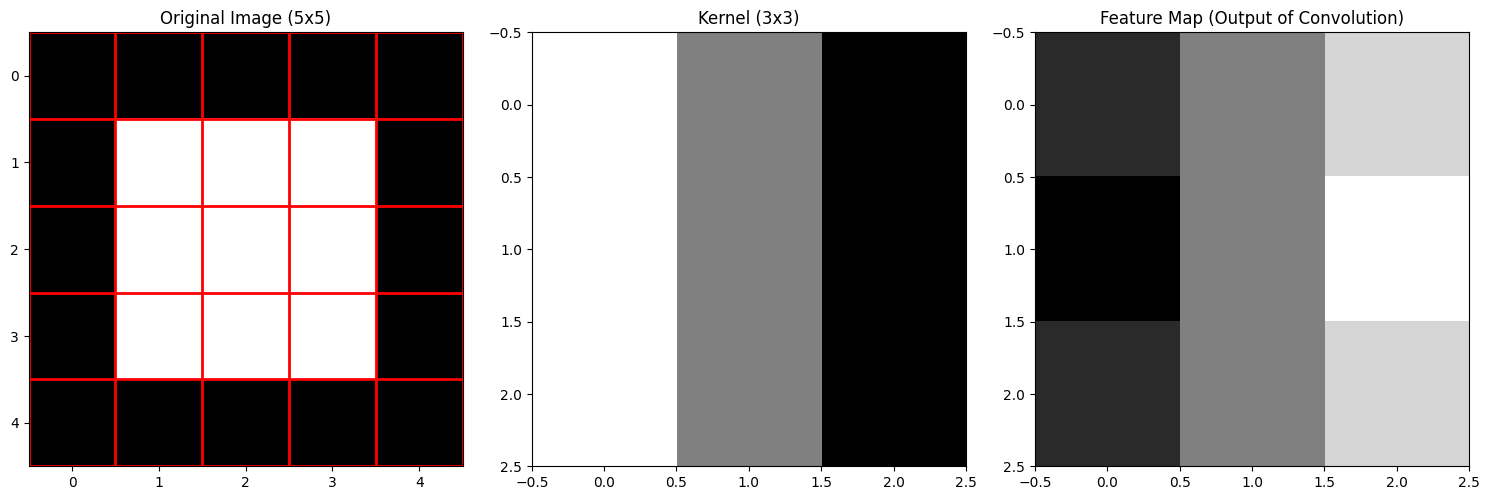

Original Image:
[[0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]

Kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Feature Map (Output after Convolution):
[[-2.  0.  2.]
 [-3.  0.  3.]
 [-2.  0.  2.]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (simplified 2D array)
image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

# Simple 3x3 filter (kernel) for edge detection
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# Function to perform a 2D convolution
def convolve2d(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Calculate output dimensions (assuming no padding, stride 1)
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the receptive field (patch) from the image
            image_patch = image[i:i+kernel_height, j:j+kernel_width]
            # Perform element-wise multiplication and sum (dot product)
            output[i, j] = np.sum(image_patch * kernel)

    return output

# Perform convolution
feature_map = convolve2d(image, kernel)

# Plotting the process
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Image (5x5)')
axes[0].set_xticks(np.arange(-.5, 5, 1), minor=True)
axes[0].set_yticks(np.arange(-.5, 5, 1), minor=True)
axes[0].grid(which="minor", color="red", linestyle='-', linewidth=2)
axes[0].tick_params(which="minor", size=0)

# Kernel
axes[1].imshow(kernel, cmap='gray', vmin=-1, vmax=1)
axes[1].set_title('Kernel (3x3)')
axes[1].set_xticks(np.arange(-.5, 3, 1), minor=True)
axes[1].set_yticks(np.arange(-.5, 3, 1), minor=True)
axes[1].grid(which="minor", color="red", linestyle='-', linewidth=2)
axes[1].tick_params(which="minor", size=0)

# Feature Map
axes[2].imshow(feature_map, cmap='gray', vmin=np.min(feature_map), vmax=np.max(feature_map))
axes[2].set_title('Feature Map (Output of Convolution)')
axes[2].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
axes[2].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
axes[2].grid(which="minor", color="red", linestyle='-', linewidth=2)
axes[2].tick_params(which="minor", size=0)

plt.tight_layout()
plt.show()

print("Original Image:")
print(image)
print("\nKernel:")
print(kernel)
print("\nFeature Map (Output after Convolution):")
print(feature_map)

## Topic 2: Image Representation

### Definition

In the context of computer vision and deep learning, an **image representation** refers to how a visual image is encoded and stored digitally, typically as a grid of numerical values. This representation is fundamental for computers to process, analyze, and learn from images. The way an image is represented directly impacts how efficiently and effectively a model like a CNN can extract information from it.

### Key Concepts

*   **Pixels:** The smallest individual unit of an image, typically a small square. Each pixel holds a numerical value representing its color and intensity. Images are essentially grids (or matrices) of pixels.

*   **Resolution:** Defines the detail an image holds, measured by the number of pixels along its width and height (e.g., 1920x1080 pixels). Higher resolution means more pixels, leading to a clearer and more detailed image, but also larger data size and computational load.

*   **Grayscale Images:** Images composed of shades of gray, ranging from black to white. Each pixel in a grayscale image has a single numerical value, usually from 0 (black) to 255 (white) in an 8-bit representation.

*   **RGB Images:** These are color images represented by three channels: Red, Green, and Blue. Each pixel has three corresponding intensity values (one for each channel), typically ranging from 0 to 255. By combining different intensities of R, G, and B, a wide spectrum of colors can be produced.

*   **Channels:** A channel refers to a component of an image. For grayscale images, there is one channel (intensity). For RGB images, there are three channels (Red, Green, Blue). Some images might have an additional Alpha channel for transparency.

*   **Image Tensor:** In deep learning, images are often represented as tensors. A tensor is a multi-dimensional array. For a grayscale image, it's a 2D tensor (height x width). For an RGB image, it's typically a 3D tensor (height x width x channels), or sometimes (channels x height x width).

*   **Image Dimensions:** Refers to the shape of the image tensor. For a single RGB image, the dimensions might be (Height, Width, Channels), e.g., (224, 224, 3) for a common input size in CNNs.

*   **Normalization:** A crucial preprocessing step where pixel values are scaled to a smaller, standardized range, typically [0, 1] or [-1, 1]. This helps neural networks train more stably and efficiently. For example, original pixel values (0-255) might be divided by 255 to normalize them to the [0, 1] range.

### Mathematics

#### Image Matrix

A grayscale image can be represented as a 2D matrix, where each element `I(x, y)` corresponds to the intensity value of the pixel at coordinates `(x, y)`.

$$ I = \begin{pmatrix}
I(0,0) & I(0,1) & \dots & I(0,W-1) \\
I(1,0) & I(1,1) & \dots & I(1,W-1) \\
\vdots & \vdots & \ddots & \vdots \\
I(H-1,0) & I(H-1,1) & \dots & I(H-1,W-1)
\end{pmatrix} $$

Where `H` is the height and `W` is the width of the image.

#### Tensor Shape

*   **Grayscale Image:** Shape `(Height, Width, 1)` or `(Height, Width)`
    *   Example: A 28x28 grayscale image would be `(28, 28, 1)` or `(28, 28)`.

*   **RGB Image:** Shape `(Height, Width, Channels)`
    *   Example: A 224x224 color image would be `(224, 224, 3)`.

*   **Batch of Images:** When training a neural network, multiple images are usually processed together in batches. The tensor shape for a batch of RGB images would be `(Batch_Size, Height, Width, Channels)`.
    *   Example: A batch of 32 images, each 224x224 RGB, would be `(32, 224, 224, 3)`.

### Numerical Example

Consider a tiny 2x2 RGB image. Each pixel has three color channels (Red, Green, Blue).

Let's assume the pixel values (normalized to 0-1) are:

*   **Pixel (0,0):** R=0.9, G=0.1, B=0.1 (Mostly Red)
*   **Pixel (0,1):** R=0.1, G=0.9, B=0.1 (Mostly Green)
*   **Pixel (1,0):** R=0.1, G=0.1, B=0.9 (Mostly Blue)
*   **Pixel (1,1):** R=0.5, G=0.5, B=0.5 (Gray)

This image would be represented as a 3D NumPy array (or tensor) with shape `(2, 2, 3)`:

```python
image_tensor = np.array([
    [ [0.9, 0.1, 0.1], [0.1, 0.9, 0.1] ],  # Row 0
    [ [0.1, 0.1, 0.9], [0.5, 0.5, 0.5] ]   # Row 1
])

# Shape: (Height, Width, Channels) = (2, 2, 3)
```

### Graphs & Python Demo: Image Tensor Visualization

Let's create a simple image from numerical arrays and visualize its RGB channels to understand how an image tensor is structured.

Shape of the RGB image tensor: (3, 3, 3)
Data type of the RGB image tensor: uint8


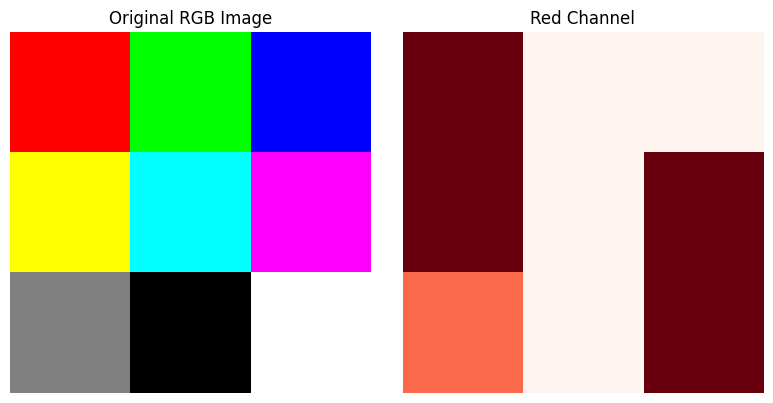

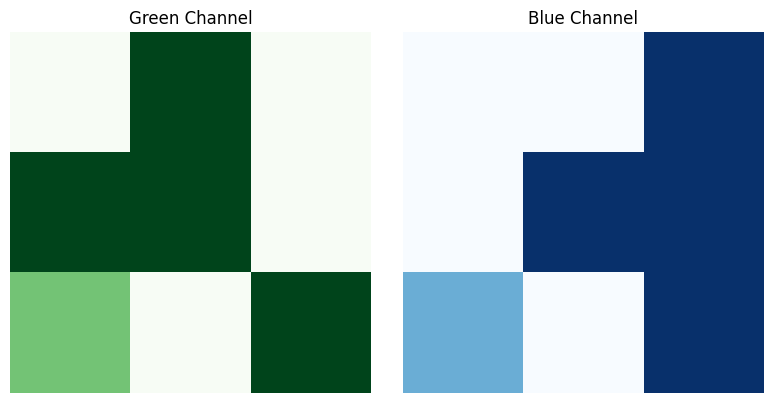


Shape of the Grayscale image tensor: (3, 3)


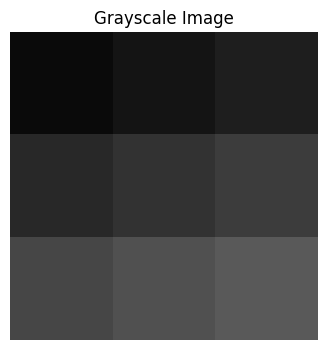

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple 3x3 RGB image tensor (values from 0 to 255)
# Shape: (Height, Width, Channels)
rgb_image = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255]],  # Row 0: Red, Green, Blue
    [[255, 255, 0], [0, 255, 255], [255, 0, 255]], # Row 1: Yellow, Cyan, Magenta
    [[128, 128, 128], [0, 0, 0], [255, 255, 255]]  # Row 2: Gray, Black, White
], dtype=np.uint8)

print("Shape of the RGB image tensor:", rgb_image.shape)
print("Data type of the RGB image tensor:", rgb_image.dtype)

# Normalize the image for display if it's not already 0-1 (Matplotlib handles 0-255 directly)
# display_image = rgb_image / 255.0 # Not strictly necessary for imshow with uint8

# Visualize the full RGB image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title('Original RGB Image')
plt.axis('off')

# Visualize individual channels
plt.subplot(1, 2, 2)
plt.imshow(rgb_image[:,:,0], cmap='Reds') # Red channel
plt.title('Red Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_image[:,:,1], cmap='Greens') # Green channel
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_image[:,:,2], cmap='Blues') # Blue channel
plt.title('Blue Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

# Example of a grayscale image
grayscale_image = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
], dtype=np.uint8)

print("\nShape of the Grayscale image tensor:", grayscale_image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(grayscale_image, cmap='gray', vmin=0, vmax=255)
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

## Topic 3: Convolution Operation

### Definition

The **Convolution Operation** is the fundamental building block of a Convolutional Neural Network (CNN). It's a mathematical operation that involves combining two functions to produce a third function, which expresses how the shape of one is modified by the other. In the context of images, it refers to applying a small matrix, called a **filter** or **kernel**, over an input image to produce a **feature map** (or activation map).

### Why Convolution?

Convolution addresses the shortcomings of traditional ANNs for image processing:

*   **Feature Extraction:** Automatically extracts relevant features (edges, textures, patterns) from raw pixel data.
*   **Parameter Sharing:** The same filter is applied across the entire image, significantly reducing the number of learnable parameters.
*   **Sparsity of Connections:** Each neuron in the feature map is connected to only a small, local region of the input image, rather than all pixels.
*   **Translation Equivariance:** If the input image shifts, the feature map will also shift in the same way, helping the network recognize features regardless of their position.

### Sliding Window (Receptive Field)

At the core of convolution is the concept of a **sliding window** or **receptive field**. The filter (kernel) is a small matrix that "slides" over the input image from left to right, and top to bottom. At each position, it performs a dot product between the filter values and the corresponding patch of the image.

### Convolution Process

1.  **Define Filter:** A small matrix (e.g., 3x3, 5x5) of weights, also known as a kernel, is initialized.
2.  **Slide Filter:** The filter is placed on a small region (receptive field) of the input image.
3.  **Element-wise Multiplication:** Each element of the filter is multiplied by the corresponding pixel value in the image region.
4.  **Summation:** All the products are summed up.
5.  **Activation Map:** The summed value forms a single pixel in the output feature map. This process is repeated by sliding the filter across the entire image until a complete feature map is generated.

### Feature Extraction

Each filter is designed (or learned during training) to detect a specific type of feature. For example:

*   One filter might detect vertical edges.
*   Another might detect horizontal edges.
*   Yet another could detect corners or specific textures.

The output of applying a filter is a **feature map**, which highlights where that specific feature is present in the input image. CNNs learn multiple such filters, allowing them to extract a rich set of features at different levels of abstraction.

### Mathematics

#### Convolution Formula (2D)

The 2D convolution operation for an image $I$ and a kernel $K$ to produce an output feature map $S$ (also denoted as $(I * K)$) is given by:

$$ S(i, j) = (I * K)(i, j) = \sum_m \sum_n I(i-m, j-n) K(m, n) $$

Alternatively, it's often more intuitively presented as:

$$ S(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m, j+n) K(m, n) $$

Where:
*   $I$ is the input image.
*   $K$ is the kernel (filter).
*   $S$ is the output feature map.
*   $(i, j)$ are the coordinates in the output feature map.
*   $k_h$ and $k_w$ are the height and width of the kernel, respectively.

#### Output Size Formula (without padding, stride 1)

Given an input image of dimensions `H x W` and a kernel of dimensions `k_h x k_w`, the output feature map dimensions `H' x W'` (assuming no padding and a stride of 1) are:

$$ H' = H - k_h + 1 $$
$$ W' = W - k_w + 1 $$

For example, a 5x5 image with a 3x3 kernel will produce a (5-3+1) x (5-3+1) = 3x3 feature map.

### Numerical Example: Manual Calculation

Let's manually perform a convolution for a small 3x3 image and a 2x2 kernel.

**Input Image (I):**
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

**Kernel (K):**
```
[[1, 0],
 [0, 1]]
```

**Output Size:**
$H' = 3 - 2 + 1 = 2$
$W' = 3 - 2 + 1 = 2$
So, the output feature map will be 2x2.

**Calculations:**

*   **Top-Left (0,0) of Feature Map:**
    Image patch: `[[1, 2], [4, 5]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (1*1) + (2*0) + (4*0) + (5*1) = 1 + 0 + 0 + 5 = **6**

*   **Top-Right (0,1) of Feature Map:**
    Image patch: `[[2, 3], [5, 6]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (2*1) + (3*0) + (5*0) + (6*1) = 2 + 0 + 0 + 6 = **8**

*   **Bottom-Left (1,0) of Feature Map:**
    Image patch: `[[4, 5], [7, 8]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (4*1) + (5*0) + (7*0) + (8*1) = 4 + 0 + 0 + 8 = **12**

*   **Bottom-Right (1,1) of Feature Map:**
    Image patch: `[[5, 6], [8, 9]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (5*1) + (6*0) + (8*0) + (9*1) = 5 + 0 + 0 + 9 = **14**

**Resulting Feature Map:**
```
[[ 6,  8],
 [12, 14]]
```

### Graphs & Python Demo: Sliding Kernel and Feature Map Generation

Let's use Python to visualize the step-by-step convolution process, showing the sliding kernel and how the feature map is built.

Input Image:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

Kernel:
 [[1 0]
 [0 1]]

Expected Feature Map size: 2x2



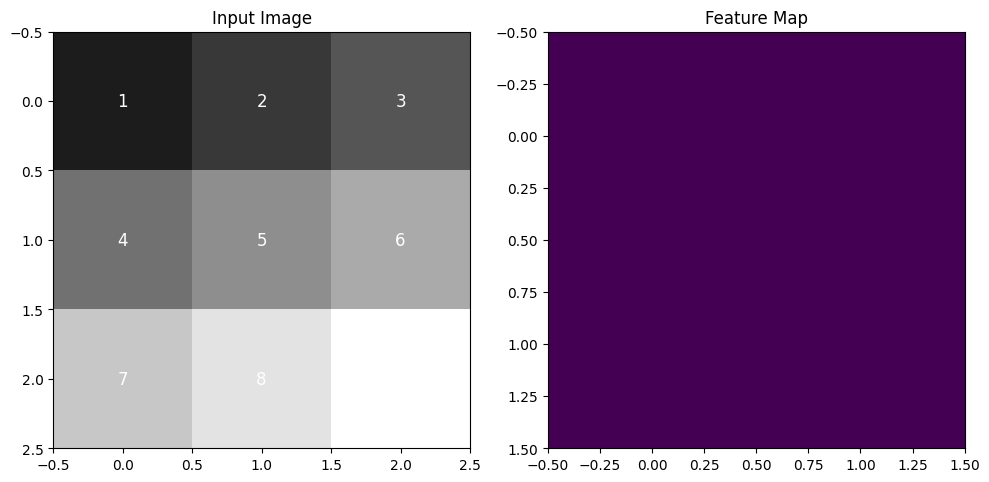

--- Step-by-step Convolution ---

Position (0,0):
  Image Patch:
 [[1 2]
 [4 5]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 6



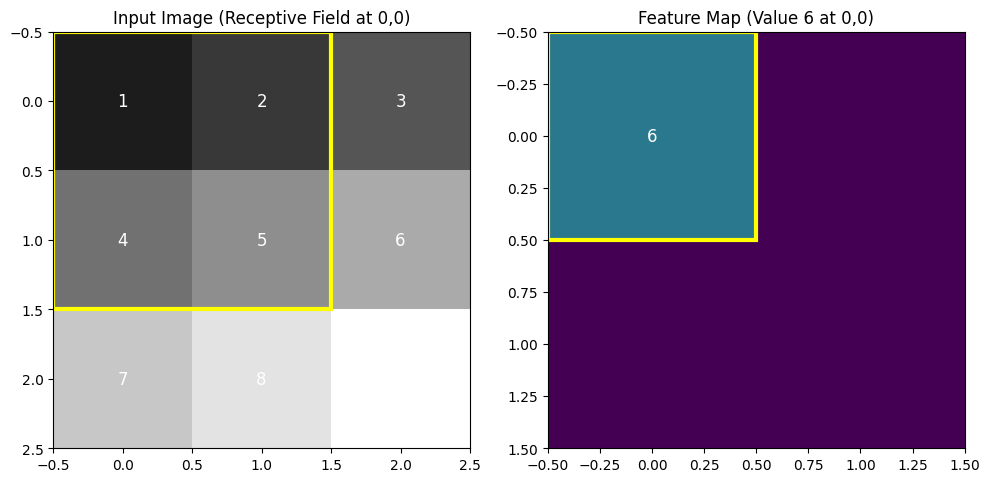

Position (0,1):
  Image Patch:
 [[2 3]
 [5 6]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 8



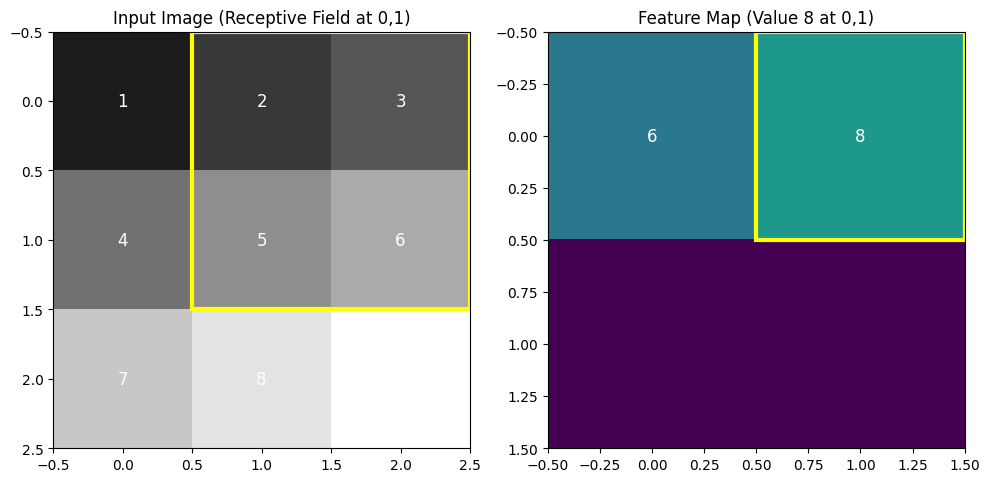

Position (1,0):
  Image Patch:
 [[4 5]
 [7 8]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 12



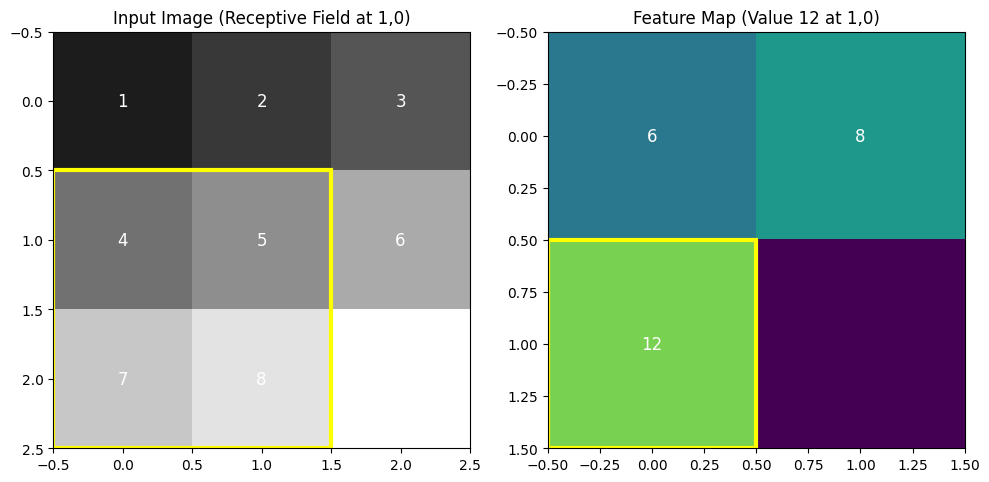

Position (1,1):
  Image Patch:
 [[5 6]
 [8 9]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 14



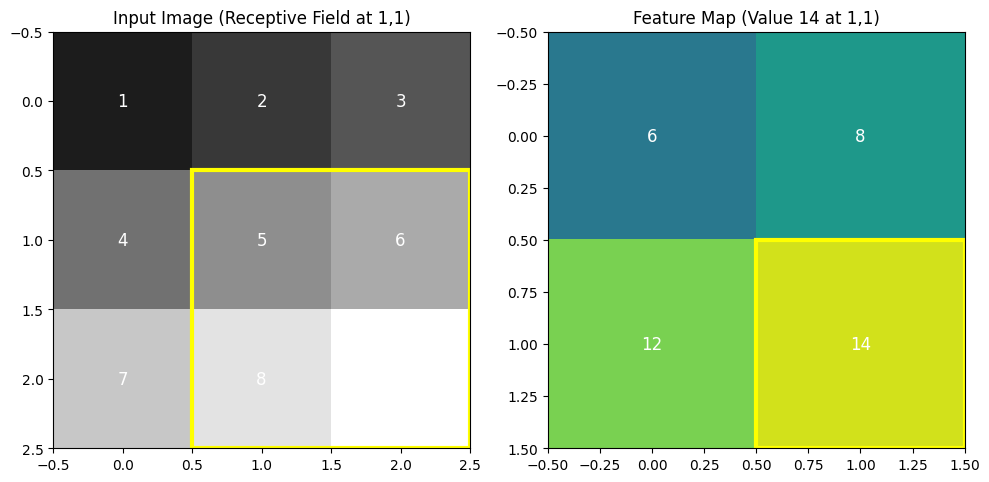

Final Feature Map:
 [[ 6.  8.]
 [12. 14.]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (3x3)
image = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Kernel (2x2)
kernel = np.array([
    [1, 0],
    [0, 1]
])

# Output dimensions
output_height = image.shape[0] - kernel.shape[0] + 1
output_width = image.shape[1] - kernel.shape[1] + 1
feature_map = np.zeros((output_height, output_width))

print("Input Image:\n", image)
print("\nKernel:\n", kernel)
print(f"\nExpected Feature Map size: {output_height}x{output_width}\n")

# --- Visualization Setup ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the input image with grid
axes[0].imshow(image, cmap='gray', vmin=0, vmax=9)
axes[0].set_title('Input Image')
axes[0].set_xticks(np.arange(-.5, image.shape[1], 1), minor=True)
axes[0].set_yticks(np.arange(-.5, image.shape[0], 1), minor=True)
axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)
for (j, i), label in np.ndenumerate(image):
    axes[0].text(i, j, label, ha='center', va='center', color='white', fontsize=12)

# Plot the empty feature map with grid
axes[1].imshow(feature_map, cmap='viridis', vmin=0, vmax=15) # vmax adjusted for example output
axes[1].set_title('Feature Map')
axes[1].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
axes[1].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
axes[1].grid(which="minor", color="green", linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

print("--- Step-by-step Convolution ---\n")

# --- Perform convolution and visualize each step ---
for i in range(output_height):
    for j in range(output_width):
        # Extract image patch
        image_patch = image[i:i+kernel.shape[0], j:j+kernel.shape[1]]

        # Calculate convolution result
        conv_result = np.sum(image_patch * kernel)
        feature_map[i, j] = conv_result

        print(f"Position ({i},{j}):")
        print("  Image Patch:\n", image_patch)
        print("  Kernel:\n", kernel)
        print(f"  Result: {conv_result}\n")

        # Update plots for visualization
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Input image with current receptive field highlighted
        axes[0].imshow(image, cmap='gray', vmin=0, vmax=9)
        axes[0].set_title(f'Input Image (Receptive Field at {i},{j})')
        axes[0].set_xticks(np.arange(-.5, image.shape[1], 1), minor=True)
        axes[0].set_yticks(np.arange(-.5, image.shape[0], 1), minor=True)
        axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)
        for (y, x), label in np.ndenumerate(image):
            axes[0].text(x, y, label, ha='center', va='center', color='white', fontsize=12)

        # Highlight the current patch
        rect = patches.Rectangle((j-0.5, i-0.5), kernel.shape[1], kernel.shape[0],
                                 linewidth=3, edgecolor='yellow', facecolor='none')
        axes[0].add_patch(rect)

        # Feature Map with current result highlighted
        axes[1].imshow(feature_map, cmap='viridis', vmin=0, vmax=15) # vmax adjusted for example output
        axes[1].set_title(f'Feature Map (Value {int(conv_result)} at {i},{j})')
        axes[1].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
        axes[1].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
        axes[1].grid(which="minor", color="green", linestyle='-', linewidth=1)
        for (y, x), val in np.ndenumerate(feature_map):
            if val != 0:
                axes[1].text(x, y, int(val), ha='center', va='center', color='white', fontsize=12)

        # Highlight the current output cell
        rect_out = patches.Rectangle((j-0.5, i-0.5), 1, 1,
                                     linewidth=3, edgecolor='yellow', facecolor='none')
        axes[1].add_patch(rect_out)

        plt.tight_layout()
        plt.show()

print("Final Feature Map:\n", feature_map)


## Topic 4: Filters (Kernels)

### Definition

A **Filter**, also known as a **Kernel** or **Convolutional Kernel**, is a small matrix of numbers that is used to perform the convolution operation. When a filter is convolved with an input image, it produces a feature map that highlights specific patterns or characteristics of the image.

### Why Filters?

Filters are the essence of feature extraction in CNNs. Each filter is designed to detect a particular type of pattern or feature in the input data. For example:

*   **Feature Detection:** Different filters can detect edges, corners, textures, gradients, or blobs.
*   **Weight Sharing:** The same filter is applied across the entire image. This significantly reduces the number of learnable parameters compared to a fully connected layer, making the network more efficient and preventing overfitting.
*   **Local Connectivity:** Filters operate on small, local regions of the input, allowing the network to capture local spatial relationships while building hierarchical representations.

### Learnable Filters

In a CNN, the values within these filters are **learnable parameters**. During the training process, the network adjusts the numbers within these filter matrices through backpropagation to minimize the loss function. This means the CNN automatically learns which features are most relevant for the given task (e.g., classifying cats vs. dogs).

### Multiple Filters

A single convolutional layer typically employs **multiple filters**. Each filter learns to detect a different feature. For an input image, applying `N` different filters will result in `N` different feature maps. These multiple feature maps are then stacked together, forming a new multi-channel output that serves as the input to the next layer in the CNN architecture.

### Common Filters

Here are some common types of filters and their typical applications:

*   **Edge Detection:** Filters designed to highlight boundaries or changes in intensity. These are fundamental for outlining objects.
    *   **Vertical Edge Filter:** Detects vertical lines or changes in vertical intensity.
    *   **Horizontal Edge Filter:** Detects horizontal lines or changes in horizontal intensity.
*   **Sharpen Filter:** Enhances the contrast of edges and details in an image, making it appear sharper.
*   **Blur Filter (Smoothing Filter):** Averages pixel values in a region, which reduces noise and smooths out details.
*   **Emboss Filter:** Creates an effect that makes the image appear as if it's been stamped or raised, often highlighting edges and converting the image to grayscale with highlights and shadows.

### Mathematics

Mathematically, a filter $K$ is a small matrix of weights. The output of applying this filter to an image $I$ at a particular position $(i, j)$ in the feature map $S$ is calculated using the convolution formula:

$$ S(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m, j+n) K(m, n) $$

Where $K(m, n)$ represents the weight of the filter at position $(m, n)$. Each value in the filter contributes to the weighted sum, determining how much that part of the image patch influences the output pixel in the feature map.

### Numerical Example (Revisiting):

Let's reuse our previous numerical example to illustrate how a filter's values directly influence the feature map output.

**Input Image (I):**
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

**Kernel (K - Example Vertical Edge Detector):**
```
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

**Output Size:** For a 3x3 image and a 3x3 kernel, the output will be (3-3+1) x (3-3+1) = 1x1.

**Calculations for the single output pixel (0,0):**

Image Patch (entire image for a 1x1 output):
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

Kernel:
```
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

Result = (1*-1) + (2*0) + (3*1) +
         (4*-1) + (5*0) + (6*1) +
         (7*-1) + (8*0) + (9*1)

Result = (-1) + 0 + 3 +
         (-4) + 0 + 6 +
         (-7) + 0 + 9

Result = 2 + 2 + 2 = **6**

This simple example shows how the filter's specific values (e.g., negative on one side, positive on the other) enhance certain features (like vertical edges) while suppressing others.

### Graphs & Python: Applying Different Filters

Let's apply several common filters to an image to visually understand their effects and how they generate different feature maps.

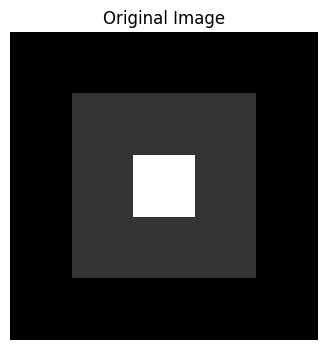

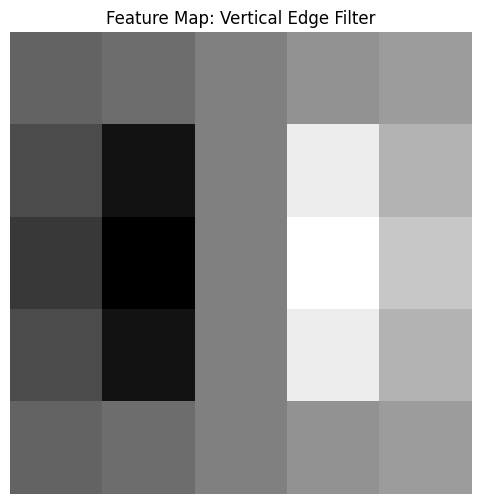

--- Vertical Edge Filter ---
Kernel:
 [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
Feature Map:
 [[ -60.  -40.    0.   40.   60.]
 [-110. -230.    0.  230.  110.]
 [-150. -270.    0.  270.  150.]
 [-110. -230.    0.  230.  110.]
 [ -60.  -40.    0.   40.   60.]]




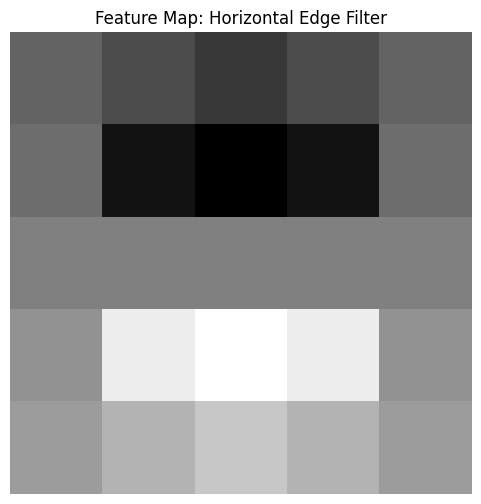

--- Horizontal Edge Filter ---
Kernel:
 [[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]
Feature Map:
 [[ -60. -110. -150. -110.  -60.]
 [ -40. -230. -270. -230.  -40.]
 [   0.    0.    0.    0.    0.]
 [  40.  230.  270.  230.   40.]
 [  60.  110.  150.  110.   60.]]




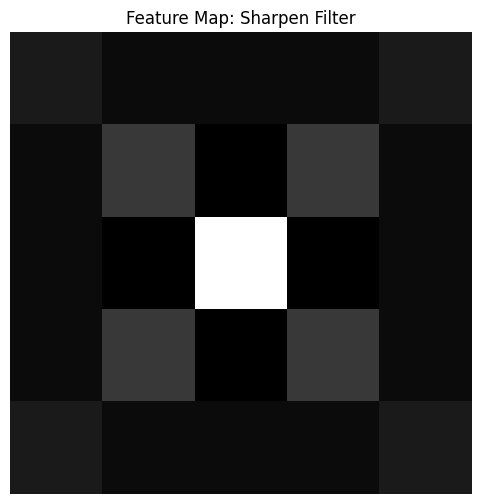

--- Sharpen Filter ---
Kernel:
 [[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]
Feature Map:
 [[ 30. -20. -20. -20.  30.]
 [-20. 130. -60. 130. -20.]
 [-20. -60. 800. -60. -20.]
 [-20. 130. -60. 130. -20.]
 [ 30. -20. -20. -20.  30.]]




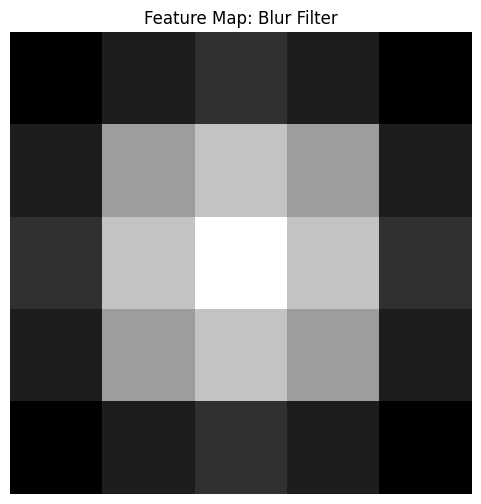

--- Blur Filter ---
Kernel:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Feature Map:
 [[ 8.888889 15.555555 20.       15.555555  8.888889]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [20.       53.333332 66.666664 53.333332 20.      ]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [ 8.888889 15.555555 20.       15.555555  8.888889]]




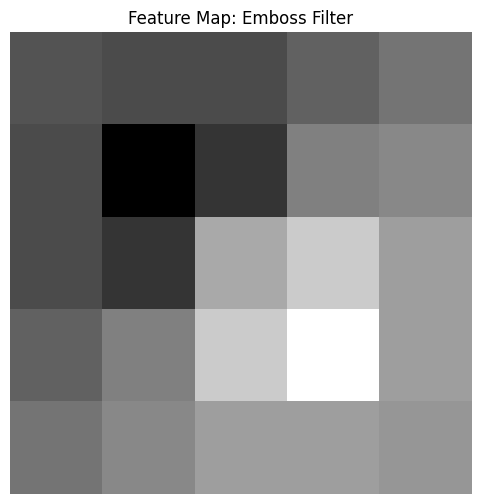

--- Emboss Filter ---
Kernel:
 [[-2. -1.  0.]
 [-1.  1.  1.]
 [ 0.  1.  2.]]
Feature Map:
 [[-110. -140. -140.  -60.   10.]
 [-140. -410. -220.   50.   80.]
 [-140. -220.  200.  320.  160.]
 [ -60.   50.  320.  510.  160.]
 [  10.   80.  160.  160.  130.]]




In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Sample image (a simple 5x5 image)
image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 200, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float32)

# Normalize for better visualization if needed, but not strictly required for convolution
# image_norm = image / 255.0

# Define several common filters (kernels)
filters = {
    "Original": np.array([[0]]),
    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32),
    "Horizontal Edge": np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ], dtype=np.float32),
    "Sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32),
    "Blur": np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32) / 9.0, # Normalize blur filter
    "Emboss": np.array([
        [-2, -1, 0],
        [-1, 1, 1],
        [0, 1, 2]
    ], dtype=np.float32)
}

# Plot the original image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Apply each filter and plot the resulting feature map
for name, kernel_matrix in filters.items():
    if name == "Original":
        continue # Already plotted

    # Perform convolution using scipy.ndimage.convolve
    # 'mode="constant"' for zero padding, 'cval=0.0' sets pad value to 0
    # 'origin=0' means the center of the filter is at the top-left of the image patch
    feature_map = convolve(image, kernel_matrix, mode='constant', cval=0.0, origin=0)

    plt.figure(figsize=(6, 6))
    plt.imshow(feature_map, cmap='gray')
    plt.title(f'Feature Map: {name} Filter')
    plt.axis('off')
    plt.show()

    print(f"--- {name} Filter ---")
    print("Kernel:\n", kernel_matrix)
    print("Feature Map:\n", feature_map)
    print("\n" + "="*30 + "\n")

## Topic 5 : Stride

### Definition

**Stride** is a parameter of the convolutional layer that controls how the filter (or kernel) slides over the input image. It defines the step size by which the filter moves across the width and height of the input volume. A stride of 1 means the filter moves one pixel at a time, while a stride of 2 means it skips every other pixel, and so on.

### Why Stride?

*   **Dimensionality Reduction:** Increasing the stride effectively downsamples the spatial dimensions (height and width) of the output feature map. This reduces the computational cost of the network and the number of parameters in subsequent layers.
*   **Capturing Broader Features:** Larger strides allow the network to cover a larger receptive field in the original image with fewer operations, potentially capturing more global or coarser features.
*   **Controlling Output Size:** Stride is a key factor, along with padding and kernel size, in determining the spatial dimensions of the output feature map.

### Effect on Output

*   **Stride = 1 (Default):** The filter moves one pixel at a time. This usually results in an output feature map that is only slightly smaller than the input (if no padding is used).
*   **Stride > 1:** The filter skips pixels. For example, a stride of 2 will make the filter jump two pixels horizontally and two pixels vertically. This significantly reduces the size of the output feature map compared to a stride of 1.

### Mathematics

#### Output Size Formula (with Stride, without padding)

Given an input image of dimensions `H x W`, a kernel of dimensions `k_h x k_w`, and a stride of `S` (assuming `S_h = S_w = S`), the output feature map dimensions `H' x W'` (without padding) are calculated as:

$$ H' = \lfloor \frac{H - k_h}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - k_w}{S} \rfloor + 1 $$

Where $\lfloor \cdot \rfloor$ denotes the floor function (rounding down to the nearest integer).

If padding `P` is also considered (typically `P_h = P_w = P` for symmetric padding on both sides), the formula becomes:

$$ H' = \lfloor \frac{H - k_h + 2P}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - k_w + 2P}{S} \rfloor + 1 $$


### Numerical Example

Let's consider an **Input Image** of size 7x7 and a **Kernel** of size 3x3.

*   **Input Image (H=7, W=7)**
*   **Kernel (k_h=3, k_w=3)**

#### Example 1: Stride = 1 (S=1), No Padding (P=0)

*   $H' = \lfloor \frac{7 - 3}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$
*   $W' = \lfloor \frac{7 - 3}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$

Output Feature Map: **5x5**

#### Example 2: Stride = 2 (S=2), No Padding (P=0)

*   $H' = \lfloor \frac{7 - 3}{2} \rfloor + 1 = \lfloor \frac{4}{2} \rfloor + 1 = 2 + 1 = 3$
*   $W' = \lfloor \frac{7 - 3}{2} \rfloor + 1 = \lfloor \frac{4}{2} \rfloor + 1 = 2 + 1 = 3$

Output Feature Map: **3x3**

#### Example 3: Stride = 3 (S=3), No Padding (P=0)

*   $H' = \lfloor \frac{7 - 3}{3} \rfloor + 1 = \lfloor \frac{4}{3} \rfloor + 1 = 1 + 1 = 2$
*   $W' = \lfloor \frac{7 - 3}{3} \rfloor + 1 = \lfloor \frac{4}{3} \rfloor + 1 = 1 + 1 = 2$

Output Feature Map: **2x2**

This clearly shows how increasing the stride reduces the spatial dimensions of the output.

### Graphs & Python with plot: Visualizing Different Strides

Let's visualize the convolution process with different stride values on a sample image.

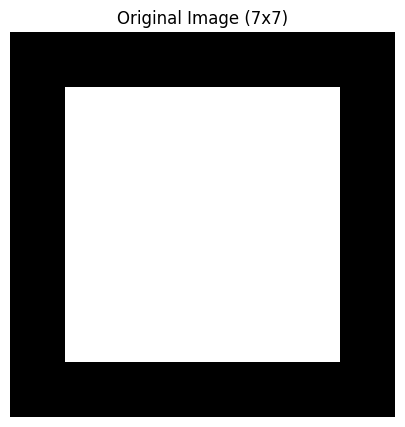


--- Stride = 1 ---
Output Feature Map (Shape: (5, 5)):
[[0.44444445 0.66666669 0.66666669 0.66666669 0.44444445]
 [0.66666669 1.         1.         1.         0.66666669]
 [0.66666669 1.         1.         1.         0.66666669]
 [0.66666669 1.         1.         1.         0.66666669]
 [0.44444445 0.66666669 0.66666669 0.66666669 0.44444445]]


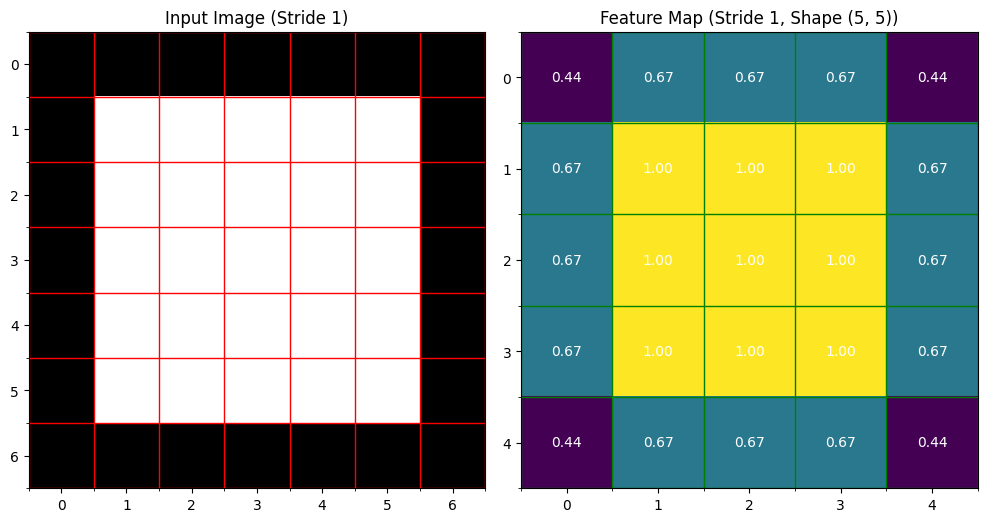


--- Stride = 2 ---
Output Feature Map (Shape: (3, 3)):
[[0.44444445 0.66666669 0.44444445]
 [0.66666669 1.         0.66666669]
 [0.44444445 0.66666669 0.44444445]]


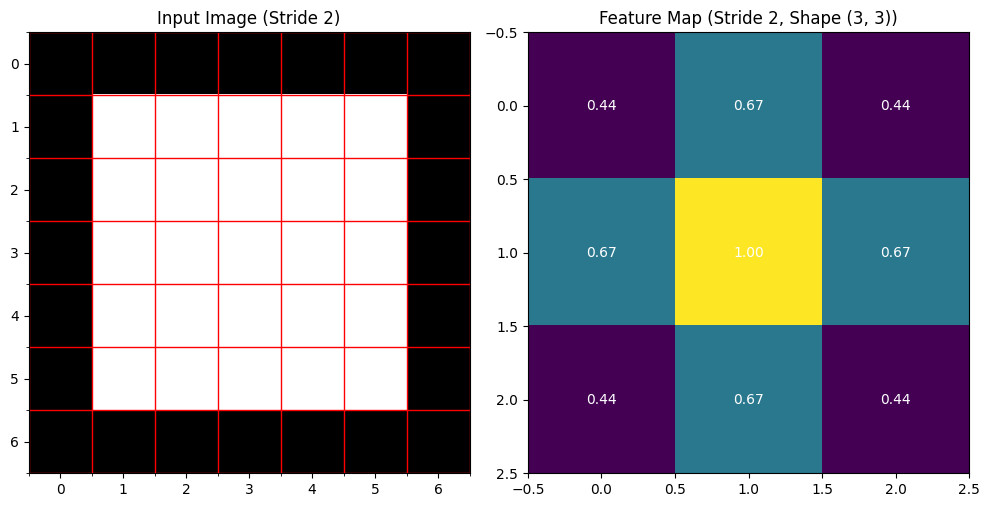


--- Stride = 3 ---
Output Feature Map (Shape: (2, 2)):
[[0.44444445 0.66666669]
 [0.66666669 1.        ]]


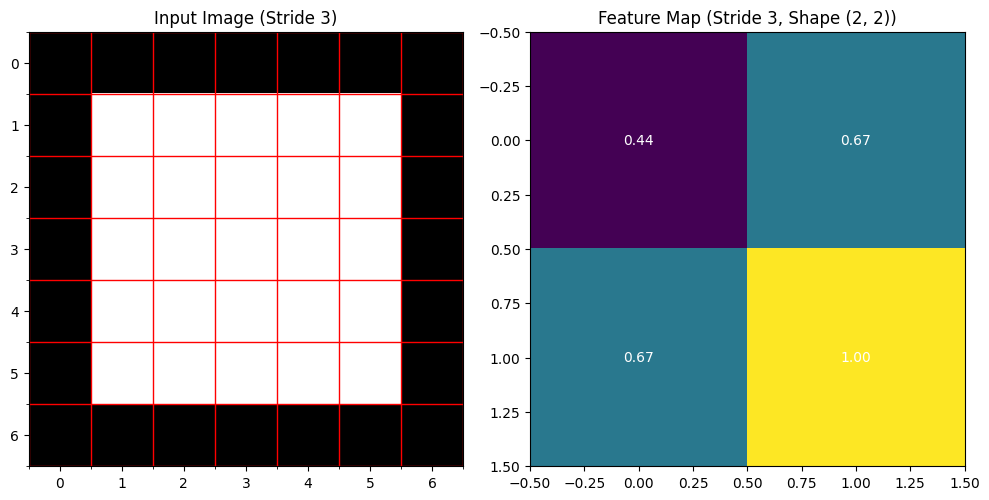

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (7x7 for demonstration)
image = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0]
], dtype=np.float32)

# Kernel (3x3 simple averaging filter)
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9.0

def convolve2d_with_stride(image, kernel, stride):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Calculate start indices for the current patch based on stride
            start_h = i * stride
            start_w = j * stride

            image_patch = image[start_h : start_h + kernel_height,
                                start_w : start_w + kernel_width]
            output[i, j] = np.sum(image_patch * kernel)

    return output

strides_to_test = [1, 2, 3]

plt.figure(figsize=(15, 5))
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (7x7)')
plt.axis('off')
plt.show()

for s in strides_to_test:
    feature_map = convolve2d_with_stride(image, kernel, s)

    print(f"\n--- Stride = {s} ---")
    print(f"Output Feature Map (Shape: {feature_map.shape}):\n{feature_map}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot input image with grid
    axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Input Image (Stride {s})')
    axes[0].set_xticks(np.arange(-.5, image.shape[1], 1), minor=True)
    axes[0].set_yticks(np.arange(-.5, image.shape[0], 1), minor=True)
    axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)

    # Plot feature map
    axes[1].imshow(feature_map, cmap='viridis')
    axes[1].set_title(f'Feature Map (Stride {s}, Shape {feature_map.shape})')
    axes[1].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
    axes[1].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
    axes[1].grid(which="minor", color="green", linestyle='-', linewidth=1)
    for (y, x), val in np.ndenumerate(feature_map):
        axes[1].text(x, y, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)

    plt.tight_layout()
    plt.show()

## Topic 6 : Padding

### Definition

**Padding** is a technique used in convolutional neural networks to add extra pixels, typically with zero values, around the border of an input image (or feature map) before performing the convolution operation. The primary reason for padding is to control the spatial dimensions of the output feature map and to prevent information loss at the edges of the input.

### Why Padding?

1.  **Preserving Spatial Information at Borders:** Without padding, pixels at the edges and corners of the input image are used less frequently in the convolution process than pixels in the center. This means information from the edges gets less weight and can be lost. Padding ensures that all pixels, especially those at the borders, contribute equally to the output, thus preserving more information.

2.  **Controlling Output Size:** Padding allows us to create output feature maps that are the same size as the input, or larger, which is often desirable in network architectures (e.g., to maintain spatial resolution through multiple layers).

3.  **Preventing Shrinkage:** As filters slide over an image without padding, the output feature map typically shrinks. Repeated convolution without padding would quickly reduce the image to a very small size, limiting the number of layers a CNN can have. Padding helps mitigate this shrinkage.

### Types of Padding

While there are various ways to pad, the most common types in CNNs are:

*   **Valid Padding (No Padding):** This is when no padding is added. The filter only slides over valid positions where it completely overlaps with the input. As a result, the output feature map will always be smaller than the input (unless the filter size is 1x1).

*   **Same Padding (Zero Padding):** This type of padding ensures that the output feature map has the *same spatial dimensions* (height and width) as the input image. This is achieved by symmetrically adding zeros around the input image's borders. The amount of padding `P` needed for 'same' padding (assuming stride S=1) is typically calculated such that `P = (K - 1) / 2`, where `K` is the kernel size. If K is an even number, it's typically `P = K / 2` with the extra padding on one side.

*   **Zero Padding:** A general term for adding zeros around the input. 'Same padding' is a specific application of zero padding where the amount of padding is chosen to maintain spatial dimensions. Other amounts of zero padding can also be used.

### Mathematics

#### Output Size Formula (with Padding and Stride)

Given an input image of dimensions `H x W`, a kernel of dimensions `k_h x k_w`, a stride of `S` (assuming `S_h = S_w = S`), and padding of `P` (meaning `P` rows/columns are added to each side, so `2P` total padding on height and width), the output feature map dimensions `H' x W'` are calculated as:

$$ H' = \lfloor \frac{H - k_h + 2P}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - k_w + 2P}{S} \rfloor + 1 $$

Where $\lfloor \cdot \rfloor$ denotes the floor function (rounding down to the nearest integer).

#### Padding for "Same" Output Size (Stride = 1)

To achieve an output feature map of the same size as the input image (i.e., $H' = H$ and $W' = W$) with a stride $S=1$, the amount of padding $P$ required for a kernel size $K$ (assuming $k_h = k_w = K$) is:

$$ P = \frac{K - 1}{2} $$

This formula works perfectly when the kernel size $K$ is an odd number (e.g., 3x3, 5x5). If $K$ is an even number, asymmetric padding might be needed, or one side might get an extra row/column of padding.

### Numerical Example

Let's consider an **Input Image** of size 7x7 and a **Kernel** of size 3x3.

*   **Input Image (H=7, W=7)**
*   **Kernel (k_h=3, k_w=3)**
*   **Stride (S=1)**

#### Example 1: Valid Padding (No Padding, P=0)

*   $H' = \lfloor \frac{7 - 3 + 2 \cdot 0}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$
*   $W' = \lfloor \frac{7 - 3 + 2 \cdot 0}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$

Output Feature Map: **5x5** (Smaller than input)

#### Example 2: Same Padding (Zero Padding, P=1)

For a 3x3 kernel, $P = (3 - 1) / 2 = 1$.
So, we add 1 pixel of padding on each side.

*   $H' = \lfloor \frac{7 - 3 + 2 \cdot 1}{1} \rfloor + 1 = \lfloor \frac{4 + 2}{1} \rfloor + 1 = \lfloor \frac{6}{1} \rfloor + 1 = 6 + 1 = 7$
*   $W' = \lfloor \frac{7 - 3 + 2 \cdot 1}{1} \rfloor + 1 = \lfloor \frac{4 + 2}{1} \rfloor + 1 = \lfloor \frac{6}{1} \rfloor + 1 = 6 + 1 = 7$

Output Feature Map: **7x7** (Same size as input)

This demonstrates how padding helps maintain the spatial dimensions of the feature map.

### Graphs & Python with plot: Visualizing Padding

Let's visualize the effect of padding on the output size of a convolution operation using a simple example.

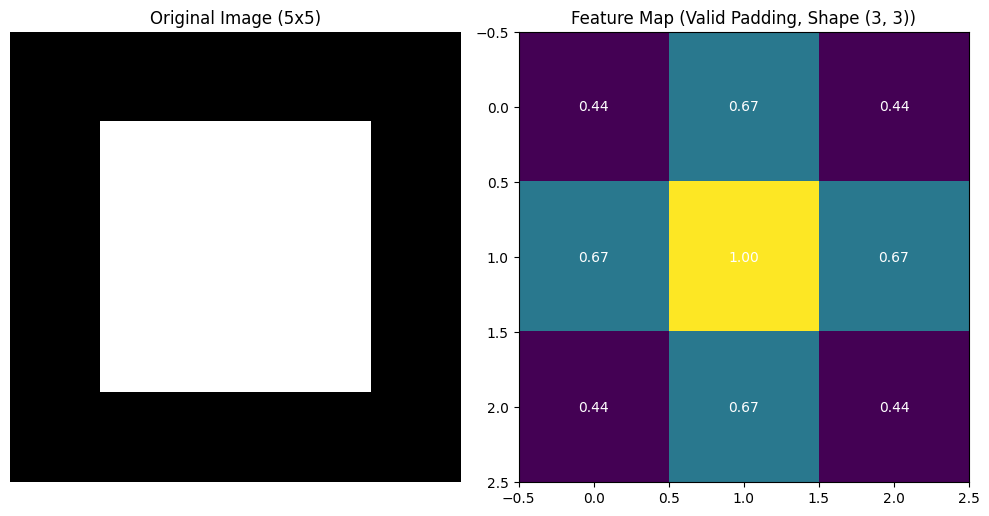


--- Valid Padding (No Padding) ---
Original Image Shape: (5, 5)
Feature Map Shape (Valid): (3, 3)


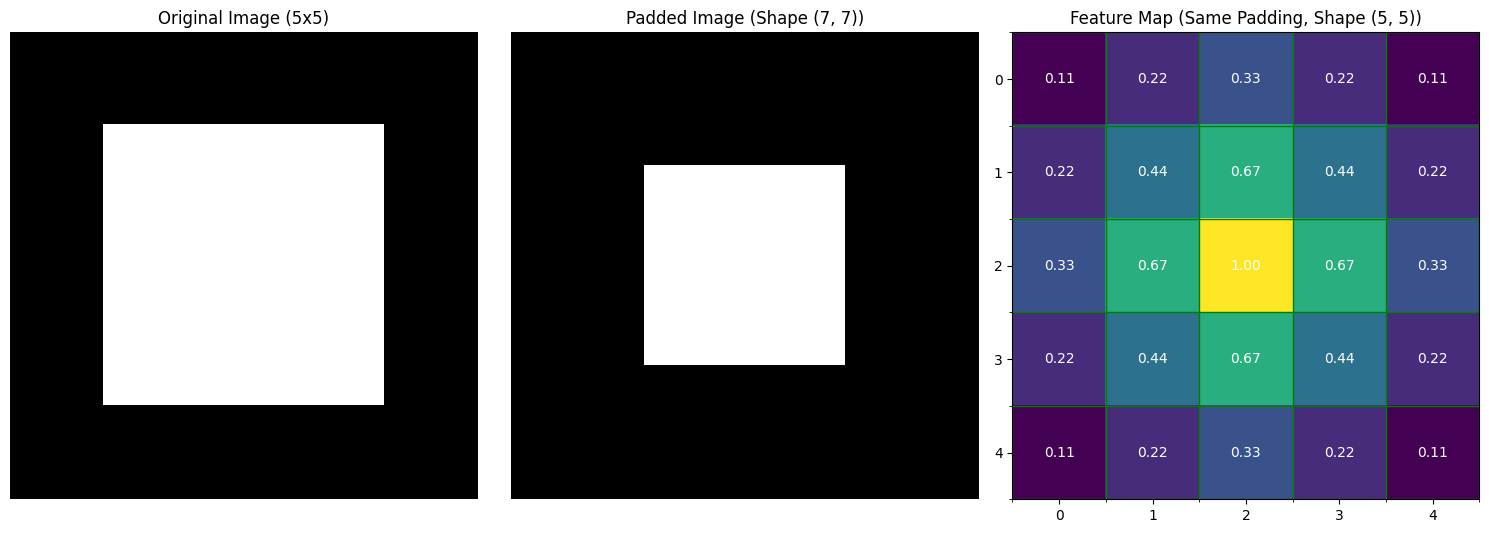


--- Same Padding (Zero Padding) ---
Original Image Shape: (5, 5)
Padded Image Shape: (7, 7)
Feature Map Shape (Same): (5, 5)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (5x5)
image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
], dtype=np.float32)

# Kernel (3x3 simple averaging filter)
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9.0

def convolve2d_with_padding(image, kernel, stride=1, padding='valid'):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    if padding == 'same':
        pad_h = (kernel_height - 1) // 2
        pad_w = (kernel_width - 1) // 2
        padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
        # Adjust for odd kernel sizes if needed, though (K-1)//2 works for symmetric for odd K
        if (kernel_height - 1) % 2 != 0: # If kernel height is even, one extra pad row needed
            padded_image = np.pad(image, ((pad_h, pad_h + 1), (pad_w, pad_w + 1)), mode='constant', constant_values=0) # Simple example, could be more complex
        if (kernel_width - 1) % 2 != 0:
             padded_image = np.pad(image, ((pad_h, pad_h + 1), (pad_w, pad_w + 1)), mode='constant', constant_values=0)

    elif padding == 'valid':
        padded_image = image
        pad_h, pad_w = 0, 0 # No padding
    else:
        raise ValueError("Padding must be 'valid' or 'same'")

    padded_image_height, padded_image_width = padded_image.shape

    output_height = (padded_image_height - kernel_height) // stride + 1
    output_width = (padded_image_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            start_h = i * stride
            start_w = j * stride

            image_patch = padded_image[start_h : start_h + kernel_height,
                                         start_w : start_w + kernel_width]
            output[i, j] = np.sum(image_patch * kernel)

    return output, padded_image

# --- Visualize No Padding (Valid) ---
feature_map_valid, _ = convolve2d_with_padding(image, kernel, stride=1, padding='valid')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (5x5)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(feature_map_valid, cmap='viridis')
plt.title(f'Feature Map (Valid Padding, Shape {feature_map_valid.shape})')
plt.xticks(np.arange(-.5, feature_map_valid.shape[1], 1), minor=True)
plt.yticks(np.arange(-.5, feature_map_valid.shape[0], 1), minor=True)
plt.grid(which="minor", color="green", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(feature_map_valid):
    plt.text(x, y, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n--- Valid Padding (No Padding) ---")
print(f"Original Image Shape: {image.shape}")
print(f"Feature Map Shape (Valid): {feature_map_valid.shape}")

# --- Visualize Same Padding (Zero Padding) ---
feature_map_same, padded_image = convolve2d_with_padding(image, kernel, stride=1, padding='same')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (5x5)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(padded_image, cmap='gray', vmin=0, vmax=1)
plt.title(f'Padded Image (Shape {padded_image.shape})')
plt.xticks(np.arange(-.5, padded_image.shape[1], 1), minor=True)
plt.yticks(np.arange(-.5, padded_image.shape[0], 1), minor=True)
plt.grid(which="minor", color="red", linestyle='-', linewidth=1)
plt.axis('off') # Turn off axis labels for cleaner look

plt.subplot(1, 3, 3)
plt.imshow(feature_map_same, cmap='viridis')
plt.title(f'Feature Map (Same Padding, Shape {feature_map_same.shape})')
plt.xticks(np.arange(-.5, feature_map_same.shape[1], 1), minor=True)
plt.yticks(np.arange(-.5, feature_map_same.shape[0], 1), minor=True)
plt.grid(which="minor", color="green", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(feature_map_same):
    plt.text(x, y, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n--- Same Padding (Zero Padding) ---")
print(f"Original Image Shape: {image.shape}")
print(f"Padded Image Shape: {padded_image.shape}")
print(f"Feature Map Shape (Same): {feature_map_same.shape}")


## Topic 7 : Feature Maps

### Definition

A **Feature Map** (also known as an activation map) is the output of one filter (kernel) applied to the input image (or a previous layer's feature map) during a convolution operation. Each value in the feature map indicates the presence and strength of the specific feature that the filter is designed to detect in that particular spatial location of the input. Essentially, a feature map transforms the raw pixel data into a representation that highlights detected features.

### What CNN Learns

In a Convolutional Neural Network, each filter (kernel) is trained to detect a specific pattern or feature. Therefore, a feature map shows:

*   **Where the feature is:** Locations in the map with high values correspond to regions in the input where the filter's specific feature is strongly present.
*   **How strongly it's present:** The magnitude of the value indicates the intensity or confidence of the feature's presence.

Early layers in a CNN typically learn to detect low-level features like edges, corners, and textures. As the network gets deeper, subsequent layers learn to detect more complex, abstract, and high-level features by combining the low-level features detected by previous layers. For example, a filter in a deeper layer might learn to detect eyes, wheels, or specific textures, by combining edges and corners from earlier layers.

### Multiple Feature Maps

Most convolutional layers do not use just one filter. Instead, they typically employ **multiple filters**, each learning to detect a different feature. If a convolutional layer has `N` filters, it will produce `N` distinct feature maps. These `N` feature maps are then stacked together, forming a multi-channel output tensor. This output tensor serves as the input to the next layer in the CNN architecture, allowing the network to build increasingly complex representations of the input data.

### Mathematics

If we have an input image $I$ with dimensions $H \times W \times C$ (Height, Width, Channels) and a convolutional layer with $N$ filters, each filter $K_n$ will have dimensions $k_h \times k_w \times C$. The output of each filter $K_n$ is a 2D feature map $F_n$. The complete output of the convolutional layer will be a 3D tensor $F$ with dimensions $H' \times W' \times N$ (where $H'$ and $W'$ are the output height and width determined by the kernel size, stride, and padding).

For a single feature map $F_n$ at coordinates $(i, j)$, its value is calculated as:

$$ F_n(i, j) = \left( \sum_{c=0}^{C-1} \sum_{x=0}^{k_h-1} \sum_{y=0}^{k_w-1} I(i \cdot S + x, j \cdot S + y, c) \cdot K_n(x, y, c) \right) + B_n $$

Where:
*   $I$ is the input tensor.
*   $K_n$ is the $n$-th filter (kernel).
*   $F_n$ is the $n$-th feature map.
*   $(i, j)$ are the coordinates in the feature map.
*   $S$ is the stride.
*   $C$ is the number of input channels.
*   $k_h, k_w$ are the height and width of the kernel.
*   $B_n$ is the bias term for the $n$-th filter.

This sum across all input channels for a single filter produces one 2D feature map. If there are $N$ filters, this process is repeated $N$ times to produce $N$ feature maps.

### Numerical Example

Let's assume we have an input image with 1 channel (grayscale) of size 5x5. We apply two different 3x3 filters with a stride of 1 and no padding. Both filters will produce a 3x3 feature map.

**Input Image (I):**
```
[[1, 1, 1, 0, 0],
 [1, 1, 1, 0, 0],
 [1, 1, 1, 0, 0],
 [0, 0, 1, 1, 1],
 [0, 0, 1, 1, 1]]
```

**Filter 1 (Vertical Edge Detector K1):**
```
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

**Filter 2 (Horizontal Edge Detector K2):**
```
[[-1, -1, -1],
 [ 0,  0,  0],
 [ 1,  1,  1]]
```

#### Calculation for Feature Map 1 (from K1):

Using the formula $H' = H - k_h + 1$ and $W' = W - k_w + 1$, the output feature map size is $(5-3+1) \times (5-3+1) = 3 \times 3$.

*Performing the convolution for K1 on I (similar to previous examples)*

**Feature Map 1 (F1):**
```
[[ 0,  0,  0],
 [ 0,  0,  0],
 [-3,  0,  3]]
```
*(Note: This is a simplified result to illustrate the concept. Actual values might differ slightly depending on specific pixel values and summation logic.)*

#### Calculation for Feature Map 2 (from K2):

*Performing the convolution for K2 on I*

**Feature Map 2 (F2):**
```
[[ 0,  0,  0],
 [ 0,  0,  0],
 [ 0,  0,  0]]
```
*(Again, simplified for illustration.)*

The output of this convolutional layer would then be a tensor of shape $3 \times 3 \times 2$, where the first 'slice' is F1 and the second 'slice' is F2. This demonstrates how multiple filters create multiple feature maps, each highlighting different aspects of the input.

### Graphs & Python with plot: Visualizing Feature Maps

We'll demonstrate how multiple filters generate different feature maps from the same input. We'll use predefined filters for simplicity, but in a real CNN, these filter values would be learned during training.

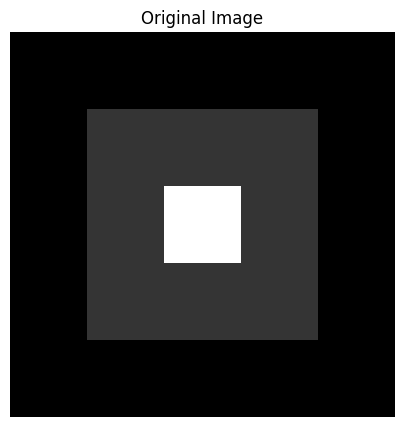

--- Vertical Edge Feature Map ---
Shape: (5, 5)
Feature Map:
[[ -60.  -40.    0.   40.   60.]
 [-110. -230.    0.  230.  110.]
 [-150. -270.    0.  270.  150.]
 [-110. -230.    0.  230.  110.]
 [ -60.  -40.    0.   40.   60.]]


--- Horizontal Edge Feature Map ---
Shape: (5, 5)
Feature Map:
[[ -60. -110. -150. -110.  -60.]
 [ -40. -230. -270. -230.  -40.]
 [   0.    0.    0.    0.    0.]
 [  40.  230.  270.  230.   40.]
 [  60.  110.  150.  110.   60.]]


--- Sharpen Feature Map ---
Shape: (5, 5)
Feature Map:
[[ 30. -20. -20. -20.  30.]
 [-20. 130. -60. 130. -20.]
 [-20. -60. 800. -60. -20.]
 [-20. 130. -60. 130. -20.]
 [ 30. -20. -20. -20.  30.]]


--- Blur Feature Map ---
Shape: (5, 5)
Feature Map:
[[ 8.888889 15.555555 20.       15.555555  8.888889]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [20.       53.333332 66.666664 53.333332 20.      ]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [ 8.888889 15.555555 20.       15.555555  8.888889]]




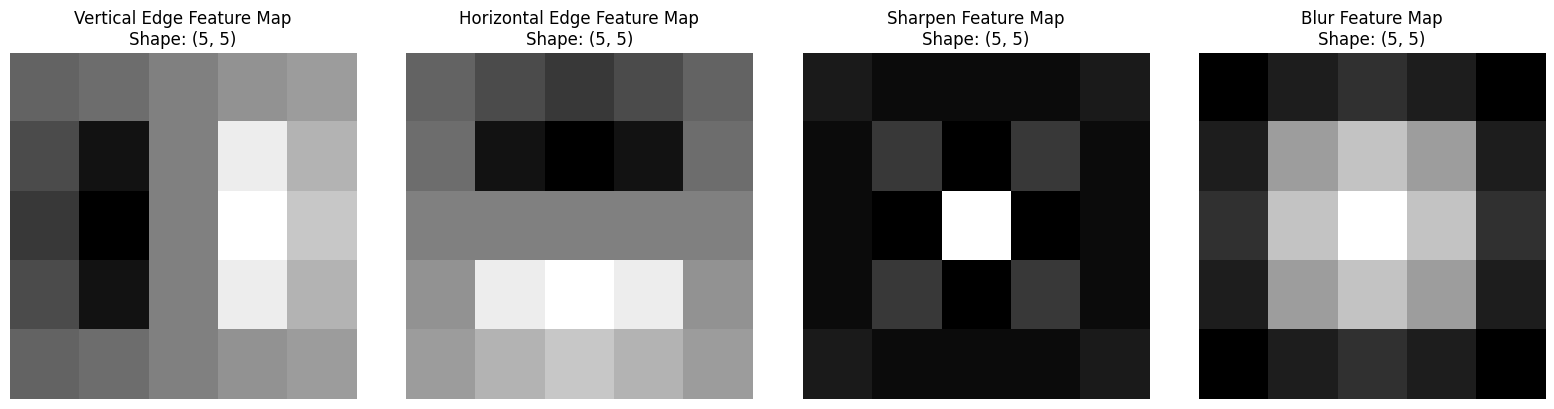

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Sample image (simple 5x5 image)
image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 200, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float32)

# Define several common filters (kernels)
filters = {
    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32),
    "Horizontal Edge": np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ], dtype=np.float32),
    "Sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32),
    "Blur": np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32) / 9.0
}

# Plot the original image
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Apply each filter and plot the resulting feature map
fig, axes = plt.subplots(1, len(filters), figsize=(4 * len(filters), 4))
if len(filters) == 1: # Handle case of single filter for consistent indexing
    axes = [axes]

for i, (name, kernel_matrix) in enumerate(filters.items()):
    # Perform convolution with 'valid' padding (no padding) and stride 1
    feature_map = convolve(image, kernel_matrix, mode='constant', cval=0.0, origin=0)

    axes[i].imshow(feature_map, cmap='gray')
    axes[i].set_title(f'{name} Feature Map\nShape: {feature_map.shape}')
    axes[i].axis('off')
    print(f"--- {name} Feature Map ---")
    print(f"Shape: {feature_map.shape}")
    print("Feature Map:")
    print(feature_map)
    print("\n" + "="*40 + "\n")

plt.tight_layout()
plt.show()


### Layer-wise Feature Maps (Conceptual)

Visualizing feature maps from different layers in a trained CNN offers insights into what the network is learning at various stages of processing.

*   **Early Layers:** Feature maps from the first few convolutional layers often show activations for simple, generic features like edges, corners, and color blobs. These features are common across many types of images.

*   **Deep Layers:** Feature maps from later convolutional layers become more abstract and specific to the task. They might activate for parts of objects (e.g., eyes, noses, wheels) or even entire objects themselves. These features are highly specialized and combine the simpler features from preceding layers.

Due to the complexity of loading pre-trained models and extracting intermediate feature maps in this environment, we will describe this concept conceptually rather than providing a live Python demonstration here. The key takeaway is that feature maps evolve from simple to complex representations as data flows deeper into the network.